# QAOA Loss Landscape on k-SAT

This notebook analyses the **loss landscape** of the Quantum Approximate Optimisation Algorithm (QAOA)
on random **k-SAT** problems. We visualise:

1. **β–γ contour plots** of the QAOA objective for a fixed layer *p* — showing the landscape structure.
2. **Layer-overlay plots** — the same β–γ landscape for *p = 1, 2, 3, …* side-by-side, so you can
   watch how deeper circuits sharpen minima.

---
**Stack:** Qiskit 2 · qiskit-aer · NumPy · Matplotlib

## 0 — Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from itertools import product as iproduct

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, SparsePauliOp

%matplotlib inline
plt.rcParams.update({
    'figure.dpi': 130,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
})
print('Imports OK')

Imports OK


## 1 — Problem definition: random k-SAT

We generate a random k-SAT instance with `n` Boolean variables and `m` clauses.
Each clause is a disjunction of `k` literals (a variable or its negation).

**Encoding:** variable $x_i \in \{0,1\}$ ↔ qubit computational basis bit.
We map to spin variables $z_i = 1 - 2x_i \in \{-1, +1\}$, so
$x_i = \frac{1-z_i}{2}$.

A **positive** literal $x_i$ is satisfied when $z_i = -1$; a **negated** literal $\bar x_i$ when $z_i = +1$.

In [2]:
def random_ksat(n_vars: int, n_clauses: int, k: int = 3, seed: int = 42):
    """
    Generate a random k-SAT instance.

    Returns
    -------
    clauses : list[list[tuple[int, int]]]
        Each clause is a list of (var_index, sign) pairs.
        sign=+1 means the literal is *positive* (x_i);
        sign=-1 means it is *negated* (¬x_i).
    """
    rng = np.random.default_rng(seed)
    clauses = []
    for _ in range(n_clauses):
        vars_ = rng.choice(n_vars, size=k, replace=False)
        signs = rng.integers(0, 2, size=k) * 2 - 1   # ±1
        clauses.append(list(zip(vars_.tolist(), signs.tolist())))
    return clauses


def check_satisfiability(n_vars: int, clauses):
    """Brute-force: count satisfying assignments."""
    satisfied = 0
    for bits in iproduct([0, 1], repeat=n_vars):
        if all(
            any((bits[v] == 0) == (s == 1) for v, s in clause)
            for clause in clauses
        ):
            satisfied += 1
    return satisfied, 2**n_vars


# ── Configuration ──────────────────────────────────────────────────────────
N_VARS    = 5     # number of Boolean variables (qubits)
K         = 3     # k in k-SAT
N_CLAUSES = 8     # number of clauses  (ratio α = m/n ≈ 1.6, below SAT threshold ≈ 4.27)
SEED      = 7

clauses = random_ksat(N_VARS, N_CLAUSES, k=K, seed=SEED)

sat_count, total = check_satisfiability(N_VARS, clauses)
print(f'{K}-SAT instance:  {N_VARS} variables,  {N_CLAUSES} clauses')
print(f'Satisfying assignments: {sat_count} / {total}  '
      f'({"SATISFIABLE" if sat_count else "UNSATISFIABLE"})')
print()
for i, cl in enumerate(clauses):
    lits = '  ∨  '.join(f'{"¬" if s==-1 else ""}x{v}' for v, s in cl)
    print(f'  Clause {i+1}: ( {lits} )')

3-SAT instance:  5 variables,  8 clauses
Satisfying assignments: 8 / 32  (SATISFIABLE)

  Clause 1: ( x2  ∨  x3  ∨  ¬x4 )
  Clause 2: ( ¬x0  ∨  ¬x1  ∨  x4 )
  Clause 3: ( ¬x0  ∨  ¬x4  ∨  ¬x3 )
  Clause 4: ( x4  ∨  x2  ∨  x1 )
  Clause 5: ( x1  ∨  ¬x3  ∨  x4 )
  Clause 6: ( x4  ∨  ¬x0  ∨  ¬x1 )
  Clause 7: ( ¬x1  ∨  x4  ∨  x0 )
  Clause 8: ( ¬x4  ∨  ¬x2  ∨  ¬x3 )


## 2 — Ising cost operator

We convert each clause into a **penalty Hamiltonian** in the Pauli-Z basis.

Each clause $C = (\ell_{i_1} \vee \ell_{i_2} \vee \ell_{i_3})$ contributes a penalty of **+1**
when *all* literals are false:

$$H_C = \prod_{j=1}^{k} \frac{1 + s_j Z_{i_j}}{2}$$

where $s_j = +1$ for a positive literal, $s_j = -1$ for a negated literal.
The total cost Hamiltonian is $H = \sum_C H_C$ (number of violated clauses).
QAOA **minimises** $\langle H \rangle$ to find satisfying assignments.

In [3]:
def ksat_to_cost_op(n_vars: int, clauses) -> SparsePauliOp:
    """
    Build the Ising cost Hamiltonian for a k-SAT instance.
    Returns a SparsePauliOp over `n_vars` qubits.
    """
    paulis: dict[str, float] = {}

    def add(label: str, coeff: float):
        paulis[label] = paulis.get(label, 0.0) + coeff

    for clause in clauses:
        k = len(clause)
        # Expand product of (1 + s_j Z_j) / 2^k  over all 2^k subsets
        for subset in iproduct([0, 1], repeat=k):
            coeff = 1.0 / (2 ** k)
            z_positions = []
            for bit, (var, sign) in zip(subset, clause):
                if bit == 1:
                    coeff *= sign
                    z_positions.append(var)
            # Build Pauli string (Qiskit: qubit 0 = rightmost character)
            label_list = ['I'] * n_vars
            for pos in z_positions:
                label_list[pos] = 'Z'
            label = ''.join(reversed(label_list))
            add(label, coeff)

    terms = [(lbl, c) for lbl, c in paulis.items() if abs(c) > 1e-12]
    return SparsePauliOp.from_list(terms)


cost_op = ksat_to_cost_op(N_VARS, clauses)
print(f'Cost operator: {len(cost_op)} Pauli terms')
print(f'Max eigenvalue (upper bound = n_clauses): {N_CLAUSES}')
print(cost_op)

Cost operator: 18 Pauli terms
Max eigenvalue (upper bound = n_clauses): 8
SparsePauliOp(['IIIII', 'ZIIII', 'IZIII', 'IIZII', 'ZIZII', 'IZZII', 'ZZZII', 'IIIZI', 'ZIIZI', 'IIIIZ', 'IIIZZ', 'ZIIZZ', 'IZIIZ', 'ZZIIZ', 'IIZZI', 'ZIZZI', 'IZIZI', 'ZZIZI'],
              coeffs=[ 1.   +0.j,  0.25 +0.j, -0.25 +0.j,  0.125+0.j,  0.125+0.j,  0.25 +0.j,
 -0.25 +0.j, -0.125+0.j, -0.125+0.j, -0.25 +0.j,  0.125+0.j,  0.125+0.j,
  0.125+0.j, -0.125+0.j,  0.125+0.j,  0.125+0.j, -0.125+0.j, -0.125+0.j])


## 3 — QAOA circuit

For $p$ layers the QAOA ansatz is:

$$|\boldsymbol{\beta}, \boldsymbol{\gamma}\rangle
= \underbrace{U_B(\beta_p) U_C(\gamma_p)}_{\text{layer }p} \cdots
  \underbrace{U_B(\beta_1) U_C(\gamma_1)}_{\text{layer }1}
  |+\rangle^{\otimes n}$$

* **Cost unitary** $U_C(\gamma) = e^{-i\gamma H}$: implemented as a sequence of RZ, RZZ, and RZZZ gates.
* **Mixer unitary** $U_B(\beta) = \bigotimes_i e^{-i\beta X_i} = \text{RX}(2\beta)^{\otimes n}$.

p=1 circuit depth: 46
p=1 circuit gate count: 61


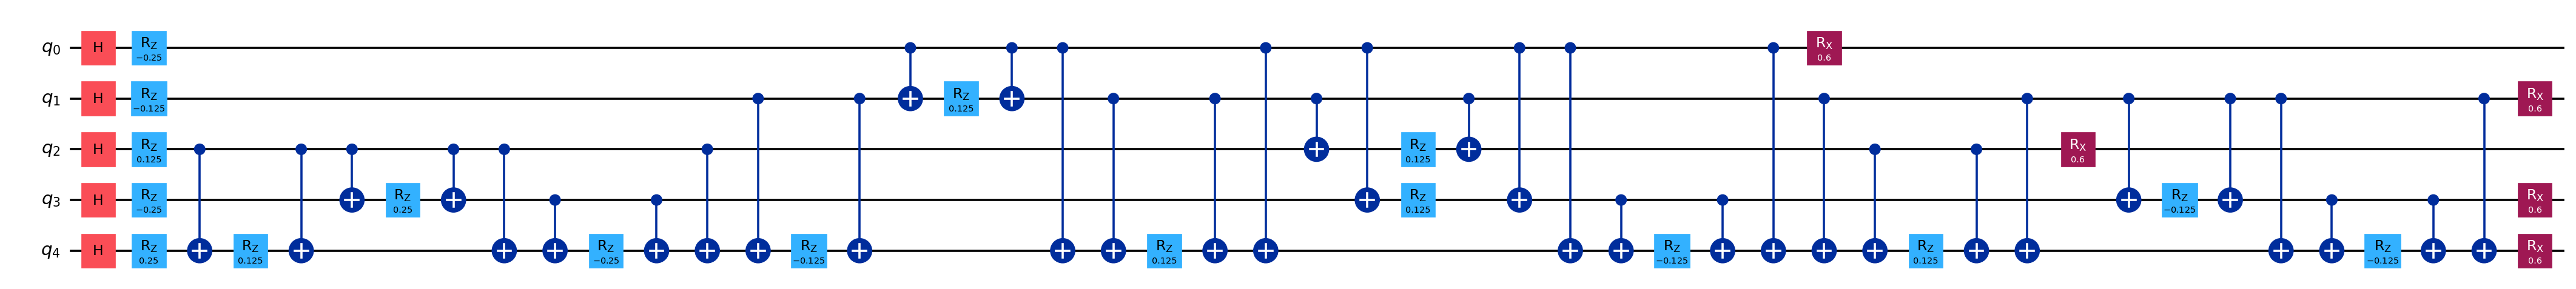

In [4]:
def apply_pauli_exp(qc: QuantumCircuit, pauli_str: str, angle: float):
    """
    Apply e^{-i * angle/2 * P} where P is a Pauli-Z product string.
    Uses CX-ladder decomposition for weight-2 and weight-3 terms.
    """
    # Qiskit stores qubits as little-endian: char[0] = highest qubit
    z_qubits = [i for i, c in enumerate(reversed(pauli_str)) if c == 'Z']
    n_z = len(z_qubits)

    if n_z == 0:
        return  # global phase
    elif n_z == 1:
        qc.rz(angle, z_qubits[0])
    elif n_z == 2:
        q0, q1 = z_qubits
        qc.cx(q0, q1)
        qc.rz(angle, q1)
        qc.cx(q0, q1)
    elif n_z == 3:
        q0, q1, q2 = z_qubits
        qc.cx(q0, q2)
        qc.cx(q1, q2)
        qc.rz(angle, q2)
        qc.cx(q1, q2)
        qc.cx(q0, q2)
    else:
        # General case: CX ladder
        for q in z_qubits[:-1]:
            qc.cx(q, z_qubits[-1])
        qc.rz(angle, z_qubits[-1])
        for q in reversed(z_qubits[:-1]):
            qc.cx(q, z_qubits[-1])


def build_qaoa_circuit(
    n: int,
    p: int,
    gammas,
    betas,
    cost_op: SparsePauliOp,
) -> QuantumCircuit:
    """
    Construct the QAOA circuit for p layers.
    gammas, betas : array-like of length p.
    """
    qc = QuantumCircuit(n)
    qc.h(range(n))                     # |+>^n initial state
    for layer in range(p):
        # ── Cost unitary U_C(gamma) ────────────────────────────────────────
        for pauli_str, coeff in zip(
            cost_op.paulis.to_labels(), cost_op.coeffs
        ):
            angle = 2.0 * gammas[layer] * float(np.real(coeff))
            apply_pauli_exp(qc, pauli_str, angle)
        # ── Mixer unitary U_B(beta) ────────────────────────────────────────
        qc.rx(2.0 * betas[layer], range(n))
    return qc


# ── Show the p=1 circuit ───────────────────────────────────────────────────
demo_qc = build_qaoa_circuit(
    N_VARS, p=1,
    gammas=[0.5], betas=[0.3],
    cost_op=cost_op,
)
print(f'p=1 circuit depth: {demo_qc.depth()}')
print(f'p=1 circuit gate count: {demo_qc.size()}')
demo_qc.draw('mpl', fold=80, style='iqp')

## 4 — Objective function

We use exact **statevector simulation** (Qiskit's `Statevector` class) to compute
the QAOA objective $F_p(\boldsymbol{\beta}, \boldsymbol{\gamma}) = \langle H \rangle$.

In [5]:
def qaoa_objective(
    n: int,
    p: int,
    gammas,
    betas,
    cost_op: SparsePauliOp,
) -> float:
    """Return <H> for QAOA with given parameters."""
    qc = build_qaoa_circuit(n, p, gammas, betas, cost_op)
    sv = Statevector(qc)
    return float(sv.expectation_value(cost_op).real)


# Quick sanity check
val = qaoa_objective(N_VARS, 1, [0.5], [0.3], cost_op)
print(f'Sample objective F_1(γ=0.5, β=0.3) = {val:.5f}')

Sample objective F_1(γ=0.5, β=0.3) = 1.35976


## 5 — β–γ Landscape for a single layer (p = 1)

We sweep $\beta \in [0, \pi]$ and $\gamma \in [0, \pi]$ on a 2-D grid
and plot the objective as a **filled contour map**.

In [6]:
# ── Grid settings ──────────────────────────────────────────────────────────
GRID_SIZE   = 60     # resolution per axis  (increase for sharper plots)
BETA_RANGE  = (0, np.pi)
GAMMA_RANGE = (0, np.pi)

betas_1d  = np.linspace(*BETA_RANGE,  GRID_SIZE)
gammas_1d = np.linspace(*GAMMA_RANGE, GRID_SIZE)


def compute_landscape_p1(betas_1d, gammas_1d):
    """Return (GRID x GRID) objective matrix for p=1."""
    Z = np.empty((len(betas_1d), len(gammas_1d)))
    for i, b in enumerate(betas_1d):
        for j, g in enumerate(gammas_1d):
            Z[i, j] = qaoa_objective(N_VARS, 1, [g], [b], cost_op)
    return Z


print(f'Computing {GRID_SIZE}×{GRID_SIZE} grid for p=1 …')
Z_p1 = compute_landscape_p1(betas_1d, gammas_1d)
print(f'Done.  min={Z_p1.min():.4f}  max={Z_p1.max():.4f}')

Computing 60×60 grid for p=1 …
Done.  min=0.3959  max=1.5886


/var/folders/jn/rj_s5dy12w3747gpn2rzn16w0000gn/T/ipykernel_17420/1631653920.py:35: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


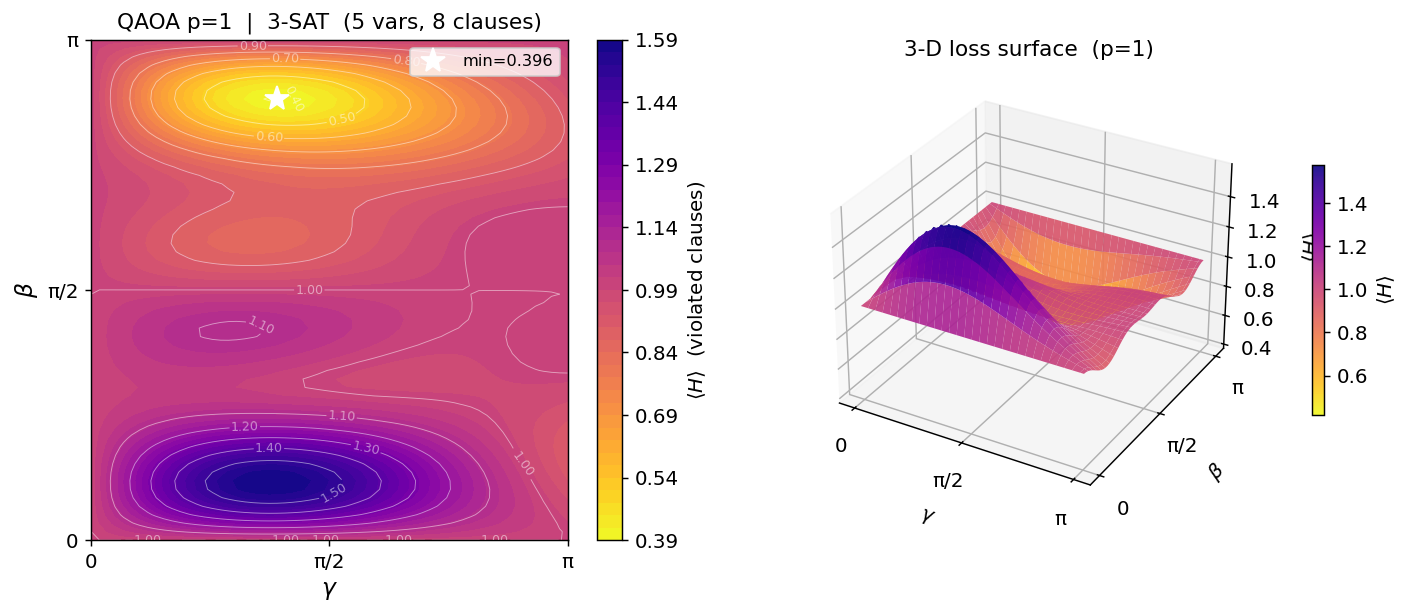

Figure saved.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
GG, BB = np.meshgrid(gammas_1d, betas_1d)   # gamma on x, beta on y

# ── Filled contour ──────────────────────────────────────────────────────────
ax = axes[0]
cf = ax.contourf(GG, BB, Z_p1, levels=40, cmap='plasma_r')
cs = ax.contour(GG, BB, Z_p1,  levels=12, colors='white', linewidths=0.5, alpha=0.5)
ax.clabel(cs, fmt='%.2f', fontsize=7, inline=True)
fig.colorbar(cf, ax=ax, label=r'$\langle H \rangle$  (violated clauses)')
ax.set_xlabel(r'$\gamma$', fontsize=13)
ax.set_ylabel(r'$\beta$', fontsize=13)
ax.set_title(f'QAOA p=1  |  {K}-SAT  ({N_VARS} vars, {N_CLAUSES} clauses)')
ax.set_xticks([0, np.pi/2, np.pi], ['0', 'π/2', 'π'])
ax.set_yticks([0, np.pi/2, np.pi], ['0', 'π/2', 'π'])

# Mark the minimum
min_idx = np.unravel_index(np.argmin(Z_p1), Z_p1.shape)
ax.plot(gammas_1d[min_idx[1]], betas_1d[min_idx[0]],
        'w*', markersize=14, label=f'min={Z_p1.min():.3f}', zorder=5)
ax.legend(fontsize=9)

# ── 3-D surface ─────────────────────────────────────────────────────────────
ax3d = fig.add_subplot(1, 2, 2, projection='3d')
axes[1].remove()   # replace placeholder
surf = ax3d.plot_surface(GG, BB, Z_p1, cmap='plasma_r',
                         linewidth=0, antialiased=True, alpha=0.92)
ax3d.set_xlabel(r'$\gamma$', labelpad=8)
ax3d.set_ylabel(r'$\beta$', labelpad=8)
ax3d.set_zlabel(r'$\langle H \rangle$', labelpad=8)
ax3d.set_xticks([0, np.pi/2, np.pi]); ax3d.set_xticklabels(['0', 'π/2', 'π'])
ax3d.set_yticks([0, np.pi/2, np.pi]); ax3d.set_yticklabels(['0', 'π/2', 'π'])
ax3d.set_title('3-D loss surface  (p=1)')
fig.colorbar(surf, ax=ax3d, shrink=0.5, pad=0.1, label=r'$\langle H \rangle$')

plt.tight_layout()
plt.savefig('landscape_p1.png', dpi=140, bbox_inches='tight')
plt.show()
print('Figure saved.')

## 6 — Layer overlay: p = 1, 2, 3, 4

For deeper QAOA ($p > 1$) we need to sweep all $2p$ parameters.
To make a 2-D slice we **fix the outer layers** at their best known values
and sweep only the **innermost** $\beta_1$ and $\gamma_1$.

This gives a comparable $\beta$–$\gamma$ slice for each $p$, letting us
observe how the landscape sharpens as we add layers.

In [9]:
# ── Linear angle schedule for fixed outer layers ────────────────────────────
def default_schedule(p: int):
    """
    A simple heuristic starting schedule:
    gamma_l = (l/p) * pi/4,  beta_l = (1 - l/p) * pi/4
    (linear ramp, a common warm-start for QAOA).
    """
    gammas = [((i + 1) / p) * (np.pi / 4) for i in range(p)]
    betas  = [(1 - i / p)   * (np.pi / 4) for i in range(p)]
    return gammas, betas


def compute_landscape_slice(p: int, betas_1d, gammas_1d):
    """
    2-D landscape for p layers: sweep (gamma_1, beta_1),
    keep layers 2..p at default_schedule values.
    """
    g_sched, b_sched = default_schedule(p)
    Z = np.empty((len(betas_1d), len(gammas_1d)))
    for i, b in enumerate(betas_1d):
        for j, g in enumerate(gammas_1d):
            gammas = [g]  + g_sched[1:]
            betas  = [b]  + b_sched[1:]
            Z[i, j] = qaoa_objective(N_VARS, p, gammas, betas, cost_op)
    return Z


P_MAX = 4
landscapes = {}
for p in range(1, P_MAX + 1):
    print(f'  Computing p={p} landscape …', end=' ', flush=True)
    landscapes[p] = compute_landscape_slice(p, betas_1d, gammas_1d)
    mn = landscapes[p].min()
    print(f'min={mn:.4f}')

print('All landscapes ready.')

  Computing p=1 landscape … min=0.3959
  Computing p=2 landscape … min=0.6759
  Computing p=3 landscape … min=0.6949
  Computing p=4 landscape … min=0.7058
All landscapes ready.


/var/folders/jn/rj_s5dy12w3747gpn2rzn16w0000gn/T/ipykernel_17420/2293271481.py:43: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


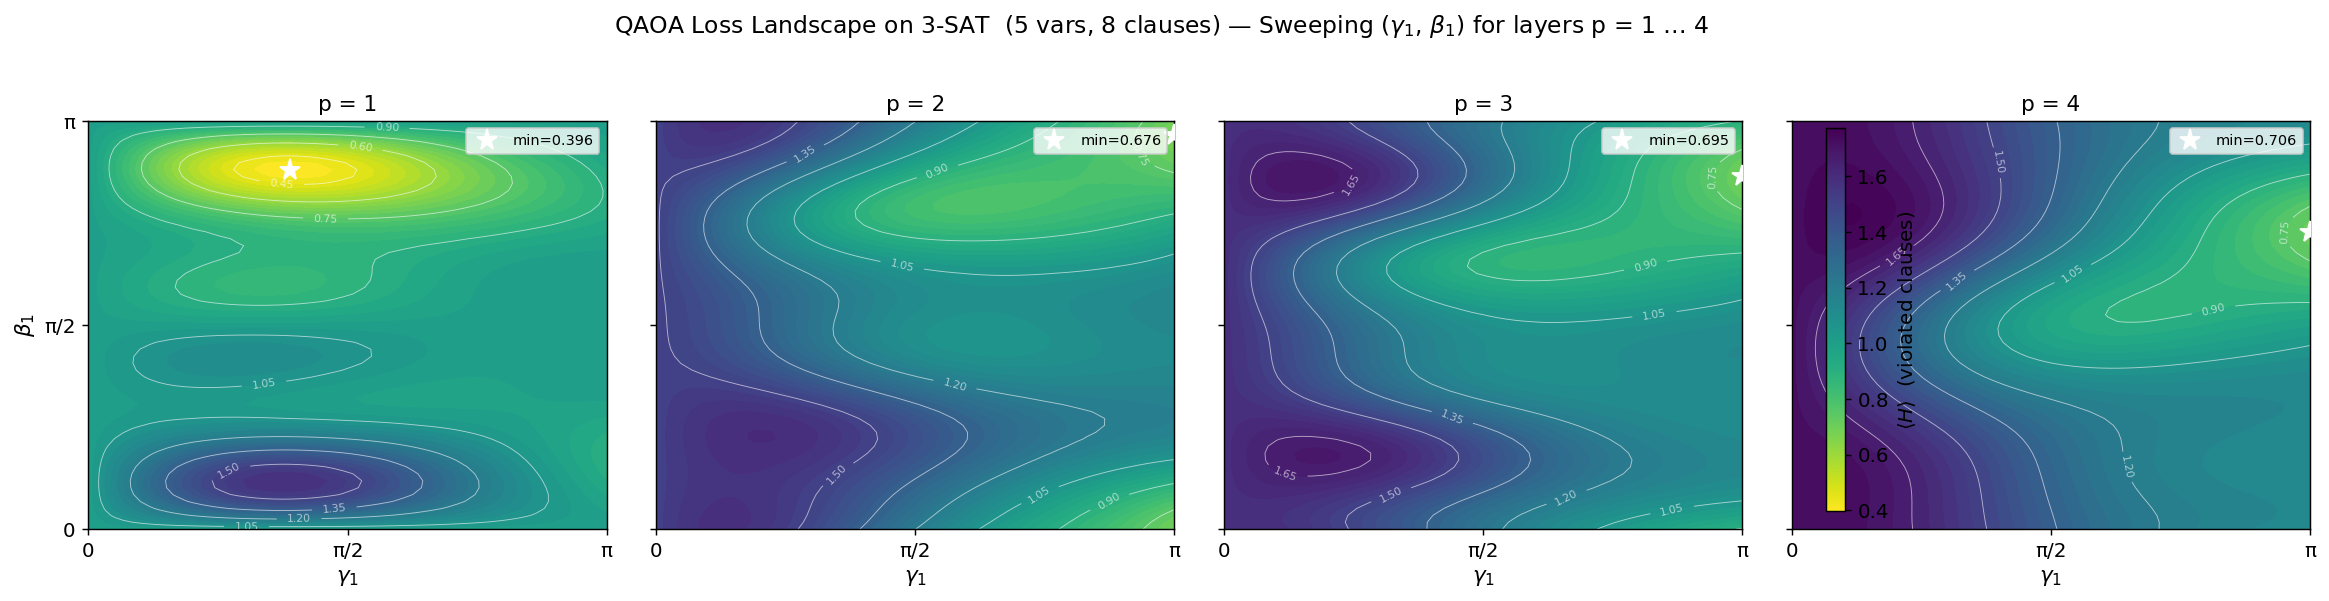

Layer overlay figure saved.


In [11]:
# ── Layer overlay contour plot ───────────────────────────────────────────────
fig, axes = plt.subplots(1, P_MAX, figsize=(4.5 * P_MAX, 4.5), sharey=True)
fig.suptitle(
    f'QAOA Loss Landscape on {K}-SAT  ({N_VARS} vars, {N_CLAUSES} clauses) — '
    r'Sweeping ($\gamma_1$, $\beta_1$) for layers p = 1 … ' + str(P_MAX),
    fontsize=13, y=1.02
)

# Shared colour range across all panels
vmin = min(Z.min() for Z in landscapes.values())
vmax = max(Z.max() for Z in landscapes.values())
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

for ax, (p, Z) in zip(axes, landscapes.items()):
    GG, BB = np.meshgrid(gammas_1d, betas_1d)
    cf = ax.contourf(GG, BB, Z, levels=40, cmap='viridis_r', norm=norm)
    cs = ax.contour(GG,  BB, Z, levels=8,  colors='white',
                     linewidths=0.5, alpha=0.6, norm=norm)
    ax.clabel(cs, fmt='%.2f', fontsize=6, inline=True)

    min_idx = np.unravel_index(np.argmin(Z), Z.shape)
    g_opt = gammas_1d[min_idx[1]]
    b_opt = betas_1d[min_idx[0]]
    ax.plot(g_opt, b_opt, 'w*', markersize=12, zorder=5,
            label=f'min={Z.min():.3f}')

    ax.set_title(f'p = {p}', fontsize=12)
    ax.set_xlabel(r'$\gamma_1$', fontsize=12)
    if ax is axes[0]:
        ax.set_ylabel(r'$\beta_1$', fontsize=12)
    ax.set_xticks([0, np.pi/2, np.pi])
    ax.set_xticklabels(['0', 'π/2', 'π'])
    ax.set_yticks([0, np.pi/2, np.pi])
    ax.set_yticklabels(['0', 'π/2', 'π'])
    ax.legend(fontsize=8, loc='upper right')

# Shared colorbar
cbar = fig.colorbar(
    plt.cm.ScalarMappable(norm=norm, cmap='viridis_r'),
    ax=axes, label=r'$\langle H \rangle$  (violated clauses)', shrink=0.85
)

plt.tight_layout()
plt.savefig('landscape_overlay.png', dpi=140, bbox_inches='tight')
plt.show()
print('Layer overlay figure saved.')

## 7 — Minimum objective vs. p (depth scaling)

Plot how the **best reachable objective** (over the grid sweep) decreases with $p$.
This illustrates the monotone non-increasing guarantee of QAOA.

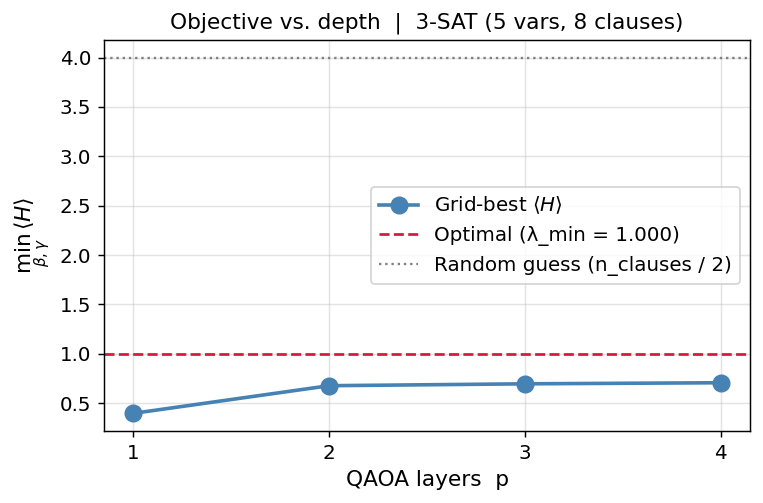

In [13]:
ps     = list(landscapes.keys())
minima = [landscapes[p].min() for p in ps]

# Classical lower bound (optimal / brute-force)
# We already have all bitstring expectations; take the min eigenvalue as floor.
import scipy.sparse.linalg as spla

try:
    H_mat = cost_op.to_matrix(sparse=True)
    eig_min = spla.eigsh(H_mat, k=1, which='SA', return_eigenvectors=False)[0]
except Exception:
    eig_min = None

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(ps, minima, 'o-', color='steelblue', linewidth=2, markersize=9,
        label=r'Grid-best $\langle H \rangle$')
if eig_min is not None:
    ax.axhline(eig_min, color='crimson', linestyle='--', linewidth=1.5,
               label=f'Optimal (λ_min = {eig_min:.3f})')
ax.axhline(N_CLAUSES / 2, color='grey', linestyle=':', linewidth=1.3,
           label='Random guess (n_clauses / 2)')

ax.set_xlabel('QAOA layers  p', fontsize=12)
ax.set_ylabel(r'$\min_{\beta,\gamma}\,\langle H \rangle$', fontsize=12)
ax.set_title(f'Objective vs. depth  |  {K}-SAT ({N_VARS} vars, {N_CLAUSES} clauses)')
ax.set_xticks(ps)
ax.legend()
ax.grid(True, alpha=0.35)

plt.tight_layout()
plt.savefig('objective_vs_p.png', dpi=140, bbox_inches='tight')
plt.show()

## 8 — Concentration landscape: variance across layers

We compute the **standard deviation** of the objective over all (β₁, γ₁) grid points
for each $p$. High variance → rough landscape (easy to find gradient);
low variance → barren plateau (gradient vanishes).

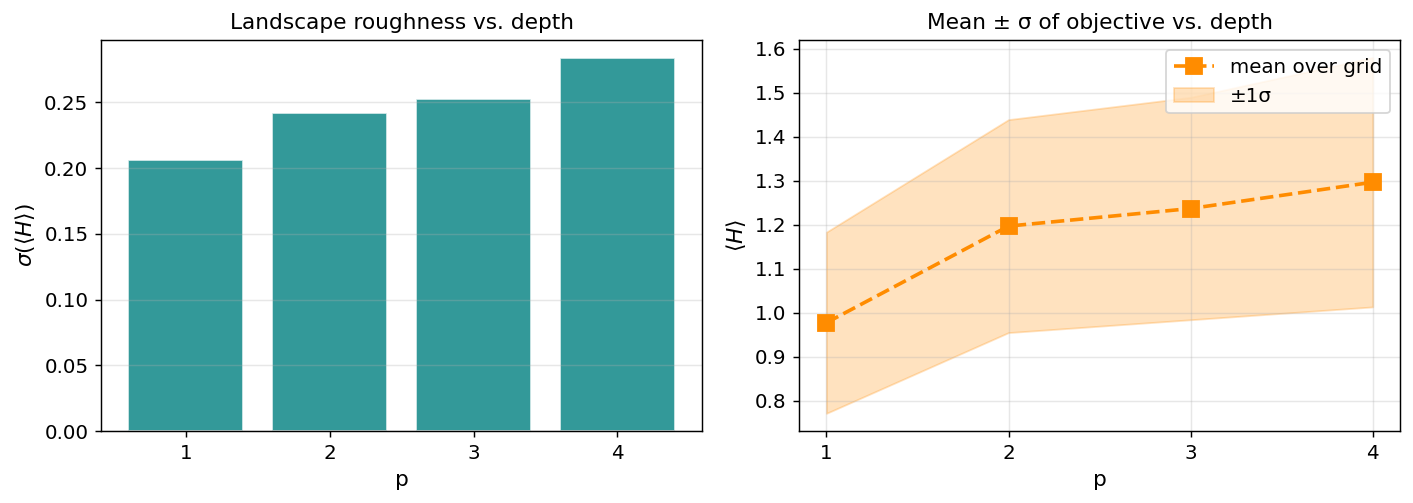

In [14]:
stds  = [landscapes[p].std()  for p in ps]
means = [landscapes[p].mean() for p in ps]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.bar(ps, stds, color='teal', alpha=0.8, edgecolor='white')
ax1.set_xlabel('p', fontsize=12)
ax1.set_ylabel(r'$\sigma(\langle H \rangle)$', fontsize=12)
ax1.set_title('Landscape roughness vs. depth')
ax1.set_xticks(ps)
ax1.grid(axis='y', alpha=0.3)

ax2.plot(ps, means, 's--', color='darkorange', linewidth=2, markersize=9,
         label='mean over grid')
ax2.fill_between(ps,
                  np.array(means) - np.array(stds),
                  np.array(means) + np.array(stds),
                  alpha=0.25, color='darkorange', label='±1σ')
ax2.set_xlabel('p', fontsize=12)
ax2.set_ylabel(r'$\langle H \rangle$', fontsize=12)
ax2.set_title('Mean ± σ of objective vs. depth')
ax2.set_xticks(ps)
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('variance_vs_p.png', dpi=140, bbox_inches='tight')
plt.show()

## 9 — Parameter path overlay

For each $p$ we record the **optimal (β₁*, γ₁*)** found by the grid scan and
draw them as a scatter on top of the p=1 landscape.
This shows how the optimal first-layer parameters shift as more layers are added.

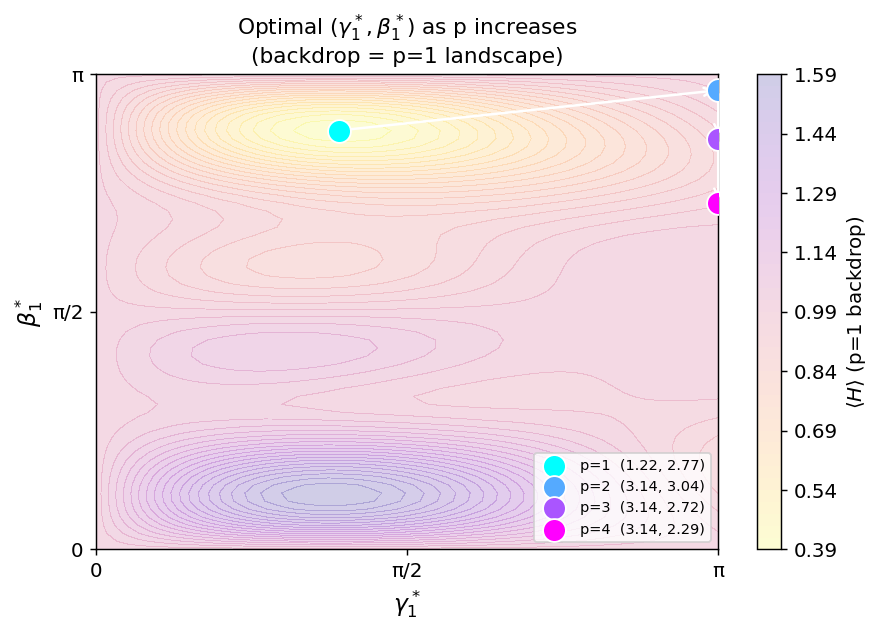

In [16]:
opt_gamma = []
opt_beta  = []
for p in ps:
    Z = landscapes[p]
    idx = np.unravel_index(np.argmin(Z), Z.shape)
    opt_gamma.append(gammas_1d[idx[1]])
    opt_beta.append(betas_1d[idx[0]])

fig, ax = plt.subplots(figsize=(7, 5))
GG, BB = np.meshgrid(gammas_1d, betas_1d)
cf = ax.contourf(GG, BB, Z_p1, levels=40, cmap='plasma_r', alpha=0.2)
fig.colorbar(cf, ax=ax, label=r'$\langle H \rangle$ (p=1 backdrop)')

colors = plt.cm.cool(np.linspace(0, 1, len(ps)))
for i, p in enumerate(ps):
    ax.scatter(opt_gamma[i], opt_beta[i], s=160, color=colors[i],
               zorder=5, edgecolors='white', linewidths=1.0,
               label=f'p={p}  ({opt_gamma[i]:.2f}, {opt_beta[i]:.2f})')

# Draw arrow path
for i in range(len(ps) - 1):
    ax.annotate('', xy=(opt_gamma[i+1], opt_beta[i+1]),
                xytext=(opt_gamma[i], opt_beta[i]),
                arrowprops=dict(arrowstyle='->', color='white', lw=1.4))

ax.set_xlabel(r'$\gamma_1^*$', fontsize=13)
ax.set_ylabel(r'$\beta_1^*$', fontsize=13)
ax.set_title('Optimal $(\\gamma_1^*, \\beta_1^*)$ as p increases\n(backdrop = p=1 landscape)')
ax.set_xticks([0, np.pi/2, np.pi]); ax.set_xticklabels(['0', 'π/2', 'π'])
ax.set_yticks([0, np.pi/2, np.pi]); ax.set_yticklabels(['0', 'π/2', 'π'])
ax.legend(fontsize=8, loc='lower right')

plt.tight_layout()
plt.savefig('optimal_params_overlay.png', dpi=140, bbox_inches='tight')
plt.show()

## 10 — Summary

| p | Grid-best ⟨H⟩ | γ₁* | β₁* | Landscape std |
|---|--------------|-----|-----|---------------|
| — | — | — | — | — |

In [17]:
import pandas as pd

rows = []
for i, p in enumerate(ps):
    Z = landscapes[p]
    rows.append({
        'p':            p,
        'min <H>':      f'{Z.min():.4f}',
        'γ₁*':          f'{opt_gamma[i]:.4f}',
        'β₁*':          f'{opt_beta[i]:.4f}',
        'mean <H>':     f'{Z.mean():.4f}',
        'std <H>':      f'{Z.std():.4f}',
    })

df = pd.DataFrame(rows).set_index('p')
print(f'\n{K}-SAT  ({N_VARS} vars, {N_CLAUSES} clauses, seed={SEED})')
if eig_min is not None:
    print(f'Optimal (min eigenvalue): {eig_min:.4f}')
print()
print(df.to_string())


3-SAT  (5 vars, 8 clauses, seed=7)
Optimal (min eigenvalue): 1.0000

  min <H>     γ₁*     β₁* mean <H> std <H>
p                                         
1  0.3959  1.2247  2.7689   0.9771  0.2058
2  0.6759  3.1416  3.0351   1.1966  0.2419
3  0.6949  3.1416  2.7156   1.2366  0.2527
4  0.7058  3.1416  2.2896   1.2963  0.2833
